In [40]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [41]:
df = pd.read_csv('../data/selected_features.csv')
df.head()

,spread1,PPE,spread2,MDVP:Fo(Hz),status
0,-4.813031,0.284654,0.266482,119.992,1
1,-4.075192,0.368674,0.335590,122.400,1
2,-4.443179,0.332634,0.311173,116.682,1
3,-4.117501,0.368975,0.334147,116.676,1
4,-3.747787,0.410335,0.234513,116.014,1


In [42]:
df.shape

(195, 5)

In [43]:
X= df.drop('status', axis=1)
y = df['status']

print("Selected Features: ")
print(X.columns.tolist())

Selected Features: 
['spread1', 'PPE', 'spread2', 'MDVP:Fo(Hz)']


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (156, 4)
Testing set size: (39, 4)


In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
grid = GridSearchCV(LogisticRegression(), param_grid = params, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)
print("Best Hyperparameters: ")
print(grid.best_params_)

Best Hyperparameters: 
{'C': 0.1, 'solver': 'lbfgs'}


In [47]:
final_model = grid.best_estimator_

final_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
y_pred = final_model.predict(X_test_scaled)

In [49]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8974


In [50]:
cv_score = cross_val_score(final_model, X_train_scaled, y_train, cv=5).mean()
print(f"Cross-Validation Accuracy: {cv_score:.4f}")

Cross-Validation Accuracy: 0.8522


In [51]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.89      1.00      0.94        32

    accuracy                           0.90        39
   macro avg       0.94      0.71      0.77        39
weighted avg       0.91      0.90      0.88        39



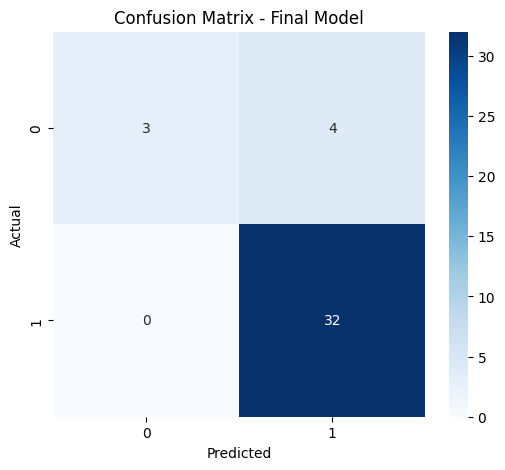

In [52]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Final Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [53]:
# Actual vs Predicted Comparison
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
print("Actual vs Predicted Comparison:")
print(comparison_df.head(10))

Actual vs Predicted Comparison:
     Actual  Predicted
138       1          1
16        1          1
155       1          1
96        1          1
68        1          1
153       1          1
55        1          1
15        1          1
112       1          1
111       1          1


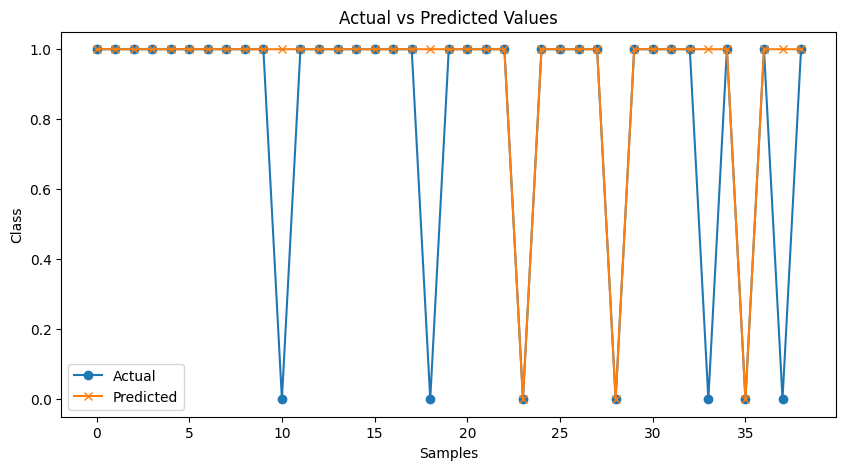

In [55]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    label="Actual",
    marker='o'
)

plt.plot(
    y_pred,
    label="Predicted",
    marker='x'
)

plt.title(
    "Actual vs Predicted Values"
)

plt.xlabel("Samples")

plt.ylabel("Class")

plt.legend()

plt.show()


Feature Coefficients:

       Feature  Coefficient
0      spread1     0.656477
1          PPE     0.633085
2      spread2     0.419257
3  MDVP:Fo(Hz)    -0.287805


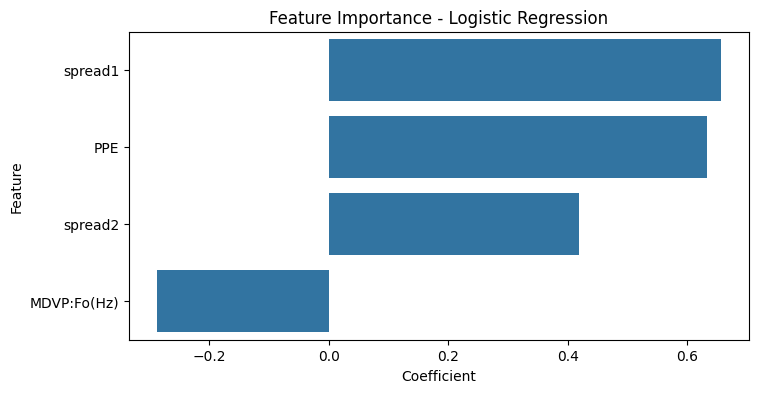

In [56]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient":
        final_model.coef_[0]
})

importance = importance.sort_values(

    by="Coefficient",

    ascending=False
)

print("\nFeature Coefficients:\n")

print(importance)

plt.figure(figsize=(8,4))

sns.barplot(x="Coefficient",y="Feature",data=importance)

plt.title("Feature Importance - Logistic Regression")

plt.show()


In [57]:
joblib.dump(final_model, '../models/final_logistic_model.pkl')
print("Final model saved to '../models/final_logistic_model.pkl'")

Final model saved to '../models/final_logistic_model.pkl'


In [58]:
comparison_df.to_csv("../results/final_predictions.csv", index=False)

print("Prediction results saved successfully.")

Prediction results saved successfully.
